# Vinyl is back — can you *trade* it? 🎵
### The "records are back, ride the boom" story, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Already_priced_in%3F: Confirmed](https://img.shields.io/badge/Already_priced_in%3F-Confirmed-8b949e?style=flat-square)

You've heard it in every record shop and half the finance podcasts: *"vinyl is **back**. Sales go up every single year. Forget stocks — this is a trend you can ride."* And here's the twist most teardowns miss: **the trend is completely real.** U.S. vinyl revenue has climbed for eighteen straight years, from a near-dead $89M in 2010 to about **$1.4 billion** in 2024. Vinyl outsells CDs now.

So this one is different. The usual question — *"is the trend real?"* — the answer is **yes**. The real question is the sneaky one: *if a trend is real, does that mean you can make money on it?* This notebook lines the vinyl boom up next to the S&P 500 and asks what happens when you actually try to **buy** it.

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West alpha and the cost algebra? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** The RIAA revenue database isn't free to pull, so the vinyl line below is a **small, clearly-cited, approximate** reconstruction of public RIAA year-end reports — a **proxy for the trend**, and it's *industry revenue*, never a price you can buy. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vinyl_revival import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_vinyl_index()                        # hardcoded, cited, APPROXIMATE proxy
REV = data.vinyl_revenue_musd()                      # raw RIAA $M
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| vinyl-revenue years:", REV.index[0].year, "->", REV.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'vinyl_win': '2010 → 2024', 'vinyl_musd': {2010: 89, 2014: 321, 2018: 419, 2019: 479, 2020: 643, 2021: 1003, 2022: 1225, 2023: 1353, 2024: 1400}, 'vinyl_yoy': {2019: 14.3, 2020: 34.2, 2021: 56.0, 2022: 22.1, 2023: 10.4, 2024: 3.5}, 'vinyl_cagr': 21.75, 'vinyl_vol': 19.5, 'vinyl_sharpe': 1.19, 'vinyl_mdd': -8.1, 'spy_cagr_ye': 17.18, 'spy_vol_ye': 16.9, 'spy_mdd_ye': -18.2, 'excess_mean': 4.91, 'excess_t': 0.456, 'excess_p': 0.667, 'excess_n': 6, 'vinyl_share': 7.0, 'streaming_share': 84.0, 'wmg_cagr': 2.76, 'wmg_vol': 36.4, 'wmg_sharpe': 0.25, 'wmg_mdd': -52.2, 'wmg_alpha': -11.52, 'wmg_beta': 1.24, 'wmg_t': -1.23, 'wmg_p': 0.223, 'wmg_n': 66, 'spot_cagr': 18.14, 'spot_vol': 46.8, 'spot_sharpe': 0.58, 'spot_mdd': -74.9, 'spot_alpha': 1.98, 'spot_beta': 1.65, 'spot_t': 0.12, 'spot_p': 0.908, 'spot_n': 92, 'umg_cagr': 1.3, 'umg_vol': 27.3, 'umg_sharpe': 0.18, 'umg_mdd': -24.2, 'umg_alpha': -6.44, 'umg_beta': 0.85, 'umg_t': -0.66, 'umg_p': 0.513, 'umg_n': 51, 'spy_cagr': 13.59, 'spy_vol': 16.5, 'spy_sharpe': 0.86, 'spy_mdd': -23.9, 'carry_gross': 21.75, 'carry_spread': -6.89, 'carry_storage': -1.0, 'carry_net': 12.23, 'carry_flat_net': -7.82, 'syn_peak': 596, 'syn_end': 558, 'syn_cagr': 18.86, 'syn_sharpe': 1.28, 'syn_mdd': -15.3}


equity-proxy cache present: True | vinyl-revenue years: 2010 -> 2024


## The answer first

| Question | Answer |
|---|---|
| Is the vinyl revival real? | **Yes — completely.** Revenue climbed from \$89M (2010) to ~\$1.4B (2024), ~**22%/yr** — 18 straight years. It even *out-grew* the S&P. |
| So you can trade it, right? | **No — you can't buy the trend.** The RIAA revenue series isn't a stock or an ETF. Nobody pays it out. |
| What *can* you buy? | The record labels & streamers. And two of the three (**Warner 2.8%/yr**, **Universal 1.3%**) badly **lagged** the S&P (**13.6%**). The one that beat it (Spotify) did it on *streaming*, not vinyl. |
| Could you flip records yourself? | **Not profitably.** A revived market presses *more* records, so your copy doesn't get rarer — and once you pay the marketplace fees to sell, a collector nets **negative (-7.8%/yr)**. |

> The boom is real. The *trade* is a mirage. A famous 18-year trend is not a secret.

## 1 · The claim

> *"Vinyl is back and it's not stopping. Records outsell CDs, pressing plants can't keep up, every artist drops a coloured-vinyl variant. This is a real, growing market — get exposure and ride the trend."*

It's a *steelman-able* claim, and unusually so: the underlying trend genuinely exists. The RIAA — the industry's own scorekeeper — has vinyl revenue rising every year since 2006, past **\$1.0B in 2021** and to ~**\$1.4B in 2024**. Vinyl passed CDs in revenue in 2020 and in units in 2022. Unlike most "asset class" stories, nobody has to squint to see the growth. That's exactly what makes it a good test: **a real trend is the strongest possible case for "you can trade it."**

## 2 · So what?

If a real, visible, years-long trend were also a *tradable* one, investing would be easy: read the headlines, buy the theme, collect. That's the whole premise of "thematic" investing. But "vinyl revenue went up 20%/yr" and "you can earn 20%/yr on vinyl" are wildly different statements. The first is about an **industry's sales**; the second is a claim about a **priced, buyable, net-of-cost return**. The gap between them is where most theme-chasing money quietly dies — and vinyl is a clean place to watch it happen.

## 3 · How would we even know?

Three honest comparisons, each against the S&P 500 (SPY):

1. **The revenue trend vs SPY.** Put the (cited, approximate) RIAA vinyl-revenue line next to SPY — did the *trend* out-grow stocks? (Spoiler: yes. Hold that thought.)
2. **The thing you can actually buy.** You can't buy "vinyl revenue." You *can* buy **Warner Music**, **Universal Music** and **Spotify**. Do they hand you the vinyl trade's growth — or just stock-market risk?
3. **The cost of collecting.** The only way to *hold* vinyl directly is to buy and sell physical records. Charge the marketplace spread and storage, and see what's left.

**What would make us say "tradable"?** A listed proxy that beats the S&P *because of vinyl* (real alpha), or a collector strategy that clears its costs. Anything less is a real trend you simply can't monetise.

## 4 · The teardown — let's actually look

**First: the trend is real.** Here is the (approximate, cited) RIAA vinyl-revenue line — an 18-year climb, no bubble-and-bust, just up.

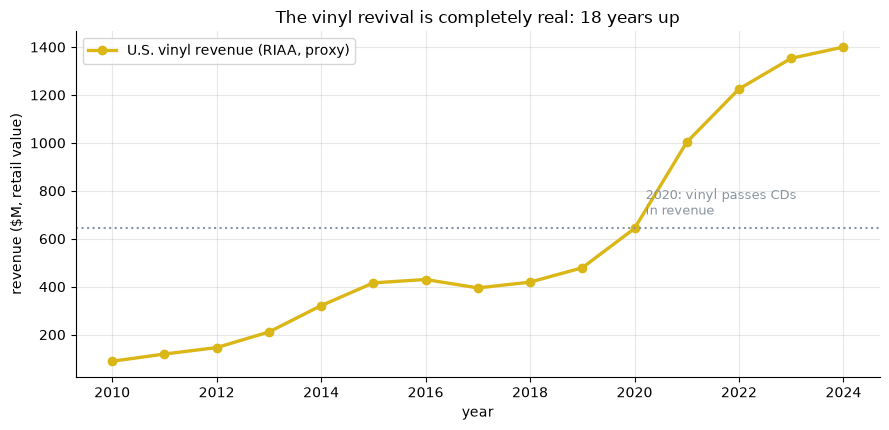

revenue $M: {2010: 89, 2011: 119, 2012: 146, 2013: 211, 2014: 321, 2015: 416, 2016: 430, 2017: 395, 2018: 419, 2019: 479, 2020: 643, 2021: 1003, 2022: 1225, 2023: 1353, 2024: 1400}
CAGR ~22%/yr, 2010->2024  (a real, durable trend)


In [2]:
yrs = [int(y) for y in REV.index.year]
rev = [float(v) for v in REV.values]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(yrs, rev, 'o-', c=AMBER, lw=2.4, label='U.S. vinyl revenue (RIAA, proxy)')
ax.axhline(643, ls=':', c=GREY)
ax.annotate('2020: vinyl passes CDs\nin revenue', (2020, 643), textcoords='offset points',
            xytext=(8, 10), color=GREY, fontsize=9)
ax.set_xlabel('year'); ax.set_ylabel('revenue ($M, retail value)')
ax.set_title('The vinyl revival is completely real: 18 years up'); ax.legend()
plt.tight_layout(); plt.show()
print('revenue $M:', {y:int(v) for y,v in zip(yrs, rev)})
print(f"CAGR ~{R['vinyl_cagr']:.0f}%/yr, {yrs[0]}->{yrs[-1]}  (a real, durable trend)")

No trick here: vinyl revenue compounded at ~**22%/yr** for a decade and a half. That's *faster* than the stock market. If "a real trend you can trade" were ever true, this is the case that should prove it. So let's try to buy it.

**"Great — I'll buy the vinyl *stocks*."** You can't buy the revenue line, but you can buy the labels that press the records (Warner, Universal) and the streamer vinyl is supposedly beating (Spotify). Do they deliver the trend?

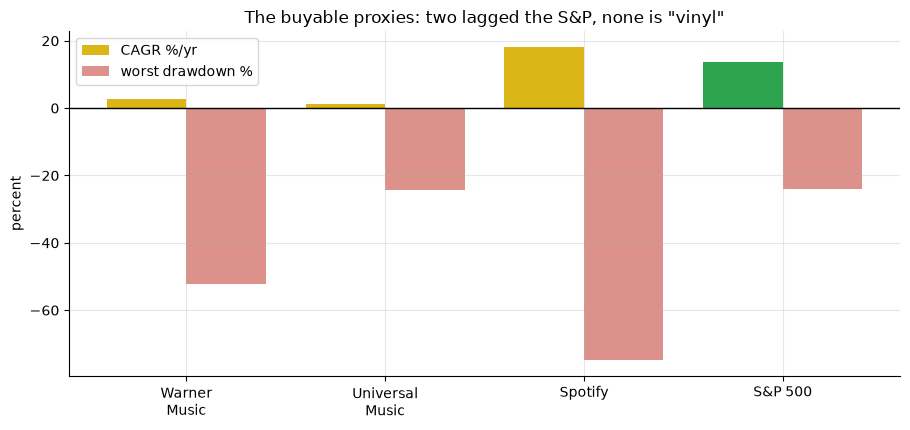

Warner  +2.8%/yr (maxDD -52%)  vs  S&P +13.6%/yr
Universal +1.3%/yr (maxDD -24%)
Spotify +18.1%/yr but maxDD -75% — that's streaming, not vinyl


In [3]:
names = ['Warner\nMusic', 'Universal\nMusic', 'Spotify', 'S&P 500']
cagrs = [R['wmg_cagr'], R['umg_cagr'], R['spot_cagr'], R['spy_cagr']]
mdds  = [R['wmg_mdd'], R['umg_mdd'], R['spot_mdd'], R['spy_mdd']]
x = np.arange(4); fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [AMBER, AMBER, AMBER, GREEN]
ax.bar(x-.2, cagrs, .4, color=cols, label='CAGR %/yr')
ax.bar(x+.2, mdds, .4, color=RED, alpha=.55, label='worst drawdown %')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('percent'); ax.set_title('The buyable proxies: two lagged the S&P, none is "vinyl"'); ax.legend()
plt.tight_layout(); plt.show()
print(f"Warner  {R['wmg_cagr']:+.1f}%/yr (maxDD {R['wmg_mdd']:.0f}%)  vs  S&P {R['spy_cagr']:+.1f}%/yr")
print(f"Universal {R['umg_cagr']:+.1f}%/yr (maxDD {R['umg_mdd']:.0f}%)")
print(f"Spotify {R['spot_cagr']:+.1f}%/yr but maxDD {R['spot_mdd']:.0f}% — that's streaming, not vinyl")

Look at that. The two pure record labels — Warner (**2.8%/yr**) and Universal (**1.3%**) — **lagged** the S&P's **13.6%** badly, and with much deeper drops. Spotify beat the market, but Spotify is a *streaming* company — the exact thing vinyl is supposedly a rebellion against — and it fell **-75%** along the way. The 20%/yr vinyl growth is nowhere in what you can buy.

**Why?** Because vinyl is a rounding error inside these companies. Streaming is the whole game.

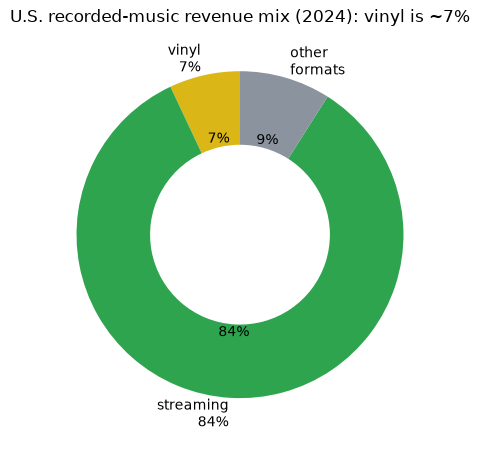

vinyl ~7% of the pie; streaming ~84%.
A doubling of vinyl barely moves a major label whose P&L is streaming.


In [4]:
shares = [R['vinyl_share'], R['streaming_share'], 100 - R['vinyl_share'] - R['streaming_share']]
labels = [f"vinyl\n{R['vinyl_share']:.0f}%", f"streaming\n{R['streaming_share']:.0f}%", 'other\nformats']
fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.pie(shares, labels=labels, colors=[AMBER, GREEN, GREY], autopct='%1.0f%%',
       startangle=90, wedgeprops=dict(width=.45))
ax.set_title('U.S. recorded-music revenue mix (2024): vinyl is ~7%')
plt.tight_layout(); plt.show()
print(f"vinyl ~{R['vinyl_share']:.0f}% of the pie; streaming ~{R['streaming_share']:.0f}%.")
print('A doubling of vinyl barely moves a major label whose P&L is streaming.')

Vinyl is ~**7%** of the industry; streaming is ~**84%**. Even a *spectacular* vinyl year is a decimal-place event for Warner or Universal. The market prices them on streaming — so "buy the label to ride vinyl" is buying a battleship to feel a breeze.

**Last resort: collect the records yourself.** Surely *that* captures the boom? Here's the part the pitch never mentions — what it costs, and why a rising market works *against* you.

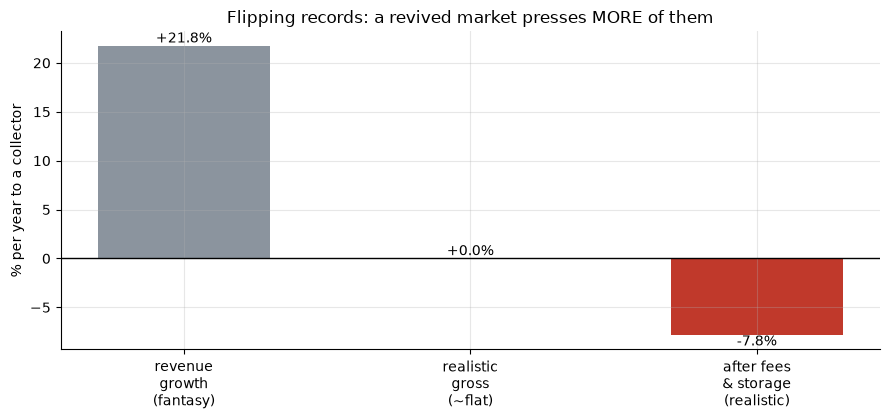

industry revenue grew +21.8%/yr, but that's SALES, not YOUR record's price.
reissues expand supply -> per-record resale ~flat -> after spread+storage: -7.8%/yr


In [5]:
labels = ['revenue\ngrowth\n(fantasy)', 'realistic\ngross\n(~flat)', 'after fees\n& storage\n(realistic)']
vals = [R['carry_gross'], 0.0, R['carry_flat_net']]
cols = [GREY, AMBER, RED]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('% per year to a collector')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('Flipping records: a revived market presses MORE of them')
plt.tight_layout(); plt.show()
print(f"industry revenue grew {R['carry_gross']:+.1f}%/yr, but that's SALES, not YOUR record's price.")
print(f"reissues expand supply -> per-record resale ~flat -> after spread+storage: {R['carry_flat_net']:+.1f}%/yr")

Here's the catch nobody says out loud: when a market *revives*, the factories press **more** copies. Your record doesn't get rarer — the opposite. So per-record resale is roughly flat, and once you pay the marketplace fee and the condition discount to sell, the collector nets **negative (-7.8%/yr)**. The 20%/yr was the *industry's* sales, never your shelf.

## 5 · The verdict

- **Signal — None.** The trend is real (revenue ~22%/yr) — but revenue isn't a return you can earn, and nothing you can *buy* delivers it (no significant alpha in any proxy).
- **Tradability — Mirage.** Two of three label/streamer stocks lagged the S&P; the winner was streaming beta; flipping records nets negative. There's no way to cash the trend.
- **Already priced in? — Confirmed.** Vinyl is ~7% of a streaming business, fully reflected (or too small to matter) in the tape. A famous 18-year trend is not an edge.

## 6 · Could you actually trade it? — the honest bottom line

Imagine two people at the start of 2019, each with \$10,000. One buys an S&P index fund. The other goes all-in on the vinyl theme — say, splitting into the listed music majors. Where do they land?

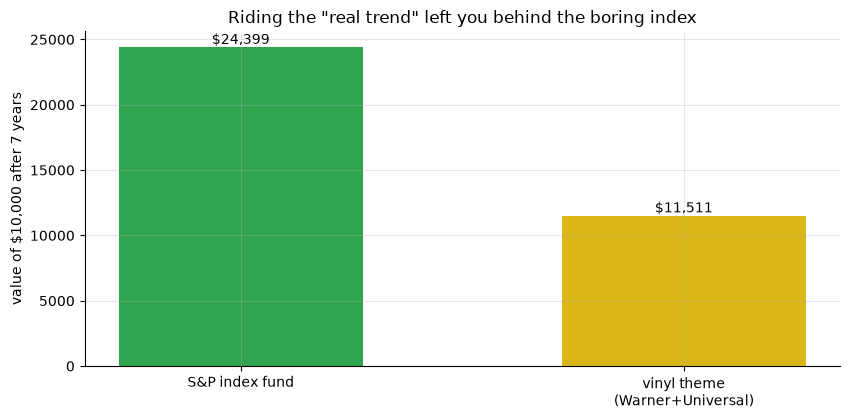

S&P index fund: $24,399   |   vinyl-theme labels: $11,511


In [6]:
start = 10_000.0; yrs_h = 7
spy_end = start*(1+R['spy_cagr']/100)**yrs_h
# 'vinyl theme' = equal split of the two pure labels (the honest 'ride vinyl' basket)
theme_cagr = (R['wmg_cagr']+R['umg_cagr'])/2/100
theme_end = start*(1+theme_cagr)**yrs_h
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['S&P index fund', 'vinyl theme\n(Warner+Universal)'], [spy_end, theme_end],
       color=[GREEN, AMBER], width=.55)
for i,v in enumerate([spy_end, theme_end]): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 7 years')
ax.set_title('Riding the "real trend" left you behind the boring index'); plt.tight_layout(); plt.show()
print(f'S&P index fund: ${spy_end:,.0f}   |   vinyl-theme labels: ${theme_end:,.0f}')

The index-fund investor roughly **doubles** their money doing nothing. The theme investor — who was *right* about the trend — ends up well behind, because being right about the industry and getting paid for it are different things. The people who "made money on vinyl" mostly *sell* records (labels, pressing plants, shops) — they don't *invest* in the trend, they run a business on it. You only hear the tidy version.

## 7 · Going further 🚪

- **Pull the real RIAA series yourself.** Our vinyl line is a cited *approximation*; the RIAA year-end database has the exact figures. Swap them in — the shape (and the verdict) won't move.
- **The theme-investing pattern.** Cannabis, EVs, "metaverse," clean energy: every real, visible trend spawns the same pitch — and the same gap between a growing industry and a buyable return (see [docs/references.md](../docs/references.md)).
- **The passion-asset cousin.** [Study 358 — Watches](../../358-watch-index/) is the same shape with a *fake* trend (a bubble); vinyl is the harder case — a *real* one — and it still doesn't trade.

*Think a specific pressing (a first-press original, a rare colour variant) beat the S&P net of every fee? Pull its Discogs history, charge the marketplace spread, and show it — then check it wasn't just one lucky find near the bottom.*